# racetraQ 07 — Light cones and classical surrogates

Notebooks [03](03_quantum_circuits_as_q_functions.ipynb)–[06](06_scaling_and_features.ipynb)
built, trained and scaled the quantum driver. This one takes it apart and asks
two questions that every variational quantum model should be asked:

- **Part A — light cones.** Which observation features can an action's
  readout $\langle Z_a\rangle$ depend on *at all*? With a nearest-neighbour CZ
  ring and a fixed number of blocks the answer is "only the ones nearby", so a
  wide circuit can be blind to some of its own inputs — and carry parameters
  and gates that provably do nothing. The same analysis tells us which gates
  to leave out on hardware.
- **Part B — classical surrogates.** The trained circuit computes a Fourier
  series in its inputs
  ([Schuld, Sweke & Meyer, Phys. Rev. A 103, 032430 (2021)](https://arxiv.org/abs/2008.08605)).
  Can a purely classical model with the same frequencies learn that function
  from input/output samples and **drive the car** — a *classical surrogate*
  in the sense of
  [Schreiber, Eisert & Meyer, Phys. Rev. Lett. 131, 100803 (2023)](https://arxiv.org/abs/2206.11740)?
- **Part C — what this does and does not mean.** The honest reading.

Everything is computed live from the bundled weights (no training, no
hardware). The prose deliberately quotes no measured numbers: read them off
the cell outputs, which are regenerated whenever the weights are.

In [1]:
# On Binder (QuBins images) this repo arrives via nbgitpuller without being
# pip-installed; install it from GitHub only if the import fails.
try:
    import racetraq  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/JanLahmann/racetraQ

import time

import matplotlib.pyplot as plt
import numpy as np

from racetraq import records
from racetraq.agents.base import action_labels
from racetraq.agents.quantum import QuantumQFunction, lightcone, surrogate
from racetraq.config import load_config
from racetraq.env.racing_env import CarObserver, RacingEnv
from racetraq.env.track import Track

# one colour per driver, the same in every figure
C_QUANTUM, C_KERNEL, C_RFF, C_GENERIC = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86"
T_START = time.perf_counter()
RESULTS = {}  # numbers collected along the way for the summary at the end

## Part A — Light cones: what a readout can see

Take the readout $Z_a$ and push it *backwards* through the circuit, last gate
first (the Heisenberg picture). A gate only matters if it fails to commute
with the operator that has reached it:

- a **CZ** spreads the operator to its neighbour only if the operator has an
  $X$/$Y$ component on one of the two qubits — a plain $Z$ commutes with CZ
  and goes nowhere;
- an **RZ** commutes with $Z$; an **RY** turns $Z$ into a mix of $Z$ and $X$,
  which the *next* CZ ring (going backwards) can then spread by one qubit.

So going back one block widens the operator's support by one qubit in each
direction around the ring. After $L$ blocks, $\langle Z_a\rangle$ can only
depend on features encoded within ring distance $L-1$ of qubit $a$ — its
**light cone** — and a ring of $n$ qubits needs $L \ge \lfloor n/2\rfloor + 1$
blocks before every readout sees every feature.
`racetraq/agents/quantum/lightcone.py` does this bookkeeping gate by gate,
without simulating a single amplitude. For each action (row) and feature
(column) the maps below count the encoding gates $RY(\lambda_{l,i}s_i)$ inside
the light cone:

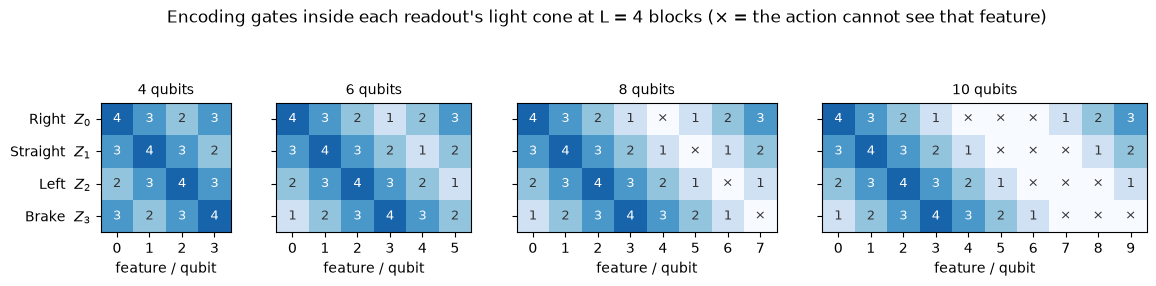

In [2]:
SIZES = (4, 6, 8, 10)
LAYERS = 4
names4 = action_labels(4)

fig, axes = plt.subplots(1, len(SIZES), figsize=(13.5, 2.9),
                         gridspec_kw={"width_ratios": SIZES})
for ax, n in zip(axes, SIZES, strict=True):
    # live encoding gates per (readout, feature); 0 = the readout cannot see the feature
    count = np.stack([lightcone.readout_live_gates(n, LAYERS, a)["enc"].sum(axis=0)
                      for a in range(4)])
    ax.imshow(count, cmap="Blues", vmin=0, vmax=LAYERS + 1, aspect="equal")
    for a in range(4):
        for j in range(n):
            ax.text(j, a, "×" if count[a, j] == 0 else str(count[a, j]), ha="center",
                    va="center", fontsize=9, color="white" if count[a, j] > 2 else "0.2")
    ax.set_xticks(range(n))
    ax.set_yticks(range(4))
    ax.set_yticklabels([f"{name}  $Z_{a}$" for a, name in enumerate(names4)]
                       if n == SIZES[0] else [])
    ax.set_xlabel("feature / qubit")
    ax.set_title(f"{n} qubits", fontsize=10)
fig.suptitle(f"Encoding gates inside each readout's light cone at L = {LAYERS} blocks "
             "(× = the action cannot see that feature)", y=1.04)
plt.show()

At 4 and 6 qubits every action still sees every feature (though the far side
of the ring through fewer and fewer gates). From 8 qubits on there are blind
spots. The same bookkeeping counts what is wasted: parameters whose gradient
is exactly zero for *every* input, and CZ gates that never influence any
readout.

In [3]:
print(f"L = {LAYERS} blocks, readout on the first 4 qubits\n")
print(f"{'qubits':>6}{'circuit params':>16}{'dead':>6}   {'(lam / RY / RZ)':<17}"
      f"{'blind action-feature pairs':>27}{'live CZ':>10}{'L for full view':>17}")
for n in SIZES:
    live = lightcone.live_gates(n, LAYERS)
    dead = {kind: int(live[kind].size - live[kind].sum()) for kind in ("enc", "ry", "rz")}
    visible = lightcone.feature_visibility(n, LAYERS)
    split = f"({dead['enc']} / {dead['ry']} / {dead['rz']})"
    print(f"{n:>6}{3 * LAYERS * n:>16}{sum(dead.values()):>6}   {split:<17}"
          f"{int((~visible).sum()):>27}{int(live['cz'].sum()):>7}/{LAYERS * n:<2}"
          f"{lightcone.min_layers_full_visibility(n):>17}")
RESULTS["dead"] = {n: sum(int(m.size - m.sum())
                          for m in lightcone.live_parameter_mask(n, LAYERS).values())
                   for n in SIZES}

L = 4 blocks, readout on the first 4 qubits

qubits  circuit params  dead   (lam / RY / RZ)   blind action-feature pairs   live CZ  L for full view
     4              48     4   (0 / 0 / 4)                                0     12/16                3
     6              72    12   (2 / 2 / 8)                                0     17/24                4
     8              96    26   (6 / 6 / 14)                               4     20/32                5
    10             120    46   (12 / 12 / 22)                            12     21/40                6


Notebook 03's teaching point — the last block's RZ gates are dead — is the
first entry of a longer list: the last block's CZ ring never matters, the
unread qubits' last rotations never matter, and so on down the cone. The dead
fraction grows with the register because the readout stays on four qubits
while the ring gets longer.

### Which action is blind to what?

Feature $j$ sits on qubit $j$, so a blind spot has a name. For the packaged
wide profiles, and for every bundled wide driver under the observation it was
actually trained with — each at the number of blocks it really has, which
need not be the four blocks of the maps above:

In [4]:
drivers = {d.id: d for d in records.discover_drivers()}
oval_track = Track.load("oval")


def load_driver(driver_id):
    '''(config, QuantumQFunction with the bundled weights) of a bundled driver.'''
    driver = drivers[driver_id]
    qfunc = QuantumQFunction(driver.config["circuit"])
    qfunc.set_params(np.load(driver.path)["params"])
    return driver.config, qfunc


def describe_blind_spots(label, config):
    names = CarObserver(oval_track, config).feature_names
    layers = int(config["circuit"]["n_layers"])
    n_actions = int(config["circuit"].get("n_actions", min(4, len(names))))
    needed = lightcone.min_layers_full_visibility(len(names), n_actions)
    print(f"{label}: {len(names)} features, L = {layers} blocks "
          f"(full visibility needs L >= {needed})")
    for line in lightcone.blind_spots(names, layers, n_actions) or ["every action sees it all"]:
        print(f"    {line}")


for profile in ("q8", "q10"):
    describe_blind_spots(f"profile {profile}", load_config(profile))
seen = set()
for d in drivers.values():
    if d.kind != "quantum" or d.n_qubits < 8:
        continue
    key = (tuple(CarObserver(oval_track, d.config).feature_names),
           d.config["circuit"]["n_layers"])
    if key not in seen:
        seen.add(key)
        describe_blind_spots(f"bundled {d.id}", d.config)

profile q8: 8 features, L = 5 blocks (full visibility needs L >= 5)
    every action sees it all
profile q10: 10 features, L = 6 blocks (full visibility needs L >= 6)
    every action sees it all
bundled quantum_oval_q8: 8 features, L = 5 blocks (full visibility needs L >= 5)
    every action sees it all
bundled quantum_oval_q10: 10 features, L = 6 blocks (full visibility needs L >= 6)
    every action sees it all
bundled quantum_gp_q10: 10 features, L = 4 blocks (full visibility needs L >= 6)
    Right (Z_0) cannot see: ray +60°, speed, curvature ahead
    Straight (Z_1) cannot see: speed, curvature ahead, lateral offset
    Left (Z_2) cannot see: curvature ahead, lateral offset, heading error
    Brake (Z_3) cannot see: lateral offset, heading error, corner speed


A line that reads "every action sees it all" is a profile or a driver with
enough blocks for its width. The `q8` profile was deepened to five blocks for
exactly this reason: at four, every action lost one feature, and *Brake* lost
the speed (the ×s in the 8-qubit map above). Whatever still prints a list has
those blind spots built in — today that is only the July `quantum_gp_q10`
file; the `q10` profile and its oval and chicane drivers run six blocks since
the 4-versus-6-block study at ten qubits (`data/studies/oval_q10`,
`chicane_q10`).

A blind spot is not a small effect to be trained away: the listed action's
Q-value is *constant* in the listed feature, whatever the parameters. Whether
that hurts depends on the pairing (a brake decision that cannot see speed is
the uncomfortable kind) — and it confounds any "more qubits" comparison in
which the extra features land outside some action's cone. For eight qubits
the two depths were trained side by side over several seeds; the summaries
are in `data/studies/oval_q8` and `data/studies/chicane_q8`.

### Don't trust the commutator argument — perturb and differentiate

The analysis above never ran the circuit. Check it against the simulator it
never touched: resample one feature at a time and see whether each readout
moves; take the gradient and see which parameters are dead. First on circuits
with generic random angles (nothing can cancel by accident), then on the
bundled wide drivers at whatever depth they were trained with.

In [5]:
def numeric_visibility(qfunc, rng, batch=64):
    '''Largest change of each <Z_a> when one feature is resampled: (actions, features).'''
    s = rng.uniform(0.0, 1.0, size=(batch, qfunc.n_features))
    before = qfunc.expectations(s)
    delta = np.zeros((qfunc.n_actions, qfunc.n_features))
    for j in range(qfunc.n_features):
        moved = s.copy()
        moved[:, j] = rng.uniform(0.0, 1.0, size=batch)
        delta[:, j] = np.abs(qfunc.expectations(moved) - before).max(axis=0)
    return delta


def numeric_gradients(qfunc, rng, batch=8):
    '''|d<Z_a>/dparam| of a randomly weighted batch, max over actions; circuit params only.'''
    s = rng.uniform(0.0, 1.0, size=(batch, qfunc.n_features))
    grad = np.zeros(qfunc.lam.size + qfunc.theta.size)
    for a in range(qfunc.n_actions):
        g = qfunc.grad_selected(s, np.full(batch, a), rng.normal(size=batch))
        grad = np.maximum(grad, np.abs(g[:grad.size] / qfunc.w[a]))  # undo the output scale
    return grad


def check_light_cone(label, qfunc, rng):
    n, layers, n_actions = qfunc.n_qubits, qfunc.n_layers, qfunc.n_actions
    visible = lightcone.feature_visibility(n, layers, n_actions)
    mask = lightcone.live_parameter_mask(n, layers, n_actions)
    live = np.concatenate([mask["lam"].ravel(), mask["theta"].ravel()])
    delta, grad = numeric_visibility(qfunc, rng), numeric_gradients(qfunc, rng)
    blind = delta[~visible].max(initial=0.0)
    dead = grad[~live].max(initial=0.0)
    assert blind < 1e-12 and dead < 1e-12, "light-cone prediction violated"
    print(f"{label:<26}{int((~visible).sum()):>6}{blind:>12.1e}{delta[visible].min():>12.1e}"
          f"{int((~live).sum()):>8}{dead:>12.1e}{grad[live].min():>12.1e}")


rng = np.random.default_rng(0)
print(f"{'':<26}{'--- resample a feature: max |d<Z>| ---':>30}"
      f"{'--- gradient: |d<Z>/dparam| ---':>36}")
print(f"{'circuit':<26}{'blind':>6}{'blind pairs':>12}{'seen pairs':>12}"
      f"{'dead':>8}{'dead':>12}{'live':>12}")
for n in SIZES:
    generic = QuantumQFunction({"n_qubits": n, "n_layers": LAYERS})
    generic.lam = rng.uniform(1.0, 4.0, size=generic.lam.shape)
    generic.theta = rng.uniform(-3.0, 3.0, size=generic.theta.shape)
    check_light_cone(f"random angles, {n} qubits", generic, rng)
for d in drivers.values():
    if d.kind == "quantum" and d.n_qubits >= 8:
        check_light_cone(f"bundled {d.id}", load_driver(d.id)[1], rng)

                          --- resample a feature: max |d<Z>| ---     --- gradient: |d<Z>/dparam| ---
circuit                    blind blind pairs  seen pairs    dead        dead        live
random angles, 4 qubits        0     0.0e+00     3.9e-01       4     9.5e-17     2.8e-02
random angles, 6 qubits        0     0.0e+00     4.8e-02      12     1.6e-16     3.2e-03
random angles, 8 qubits        4     1.3e-15     2.4e-02      26     2.0e-16     9.3e-03


random angles, 10 qubits      12     1.8e-15     1.0e-02      46     3.0e-16     3.0e-02
bundled quantum_oval_q8        0     0.0e+00     9.9e-03      26     2.3e-16     8.0e-03


bundled quantum_chicane_q8     0     0.0e+00     5.5e-03      26     2.0e-16     6.1e-03


bundled quantum_oval_q10       0     0.0e+00     1.0e-02      46     2.5e-16     1.9e-03


bundled quantum_chicane_q10     0     0.0e+00     1.3e-03      46     2.8e-16     5.1e-04


bundled quantum_gp_q10        12     3.8e-15     8.0e-04      46     2.2e-16     5.0e-04


Blind pairs do not move and dead parameters have no gradient — to within
floating-point rounding, which the assertion in the cell enforces. The
"seen" and "live" columns show the *smallest* effect among everything the
analysis predicts can matter: compare them with the blind/dead columns next
to them. For random angles that gap is the evidence that the structural bound
is tight — nothing predicted live turns out dead. In a *trained* driver a
visible feature can still have a small effect; that is the optimizer's
choice, not the cone's.

### What the light cone buys on hardware

Dead gates can simply be left out: the pruned circuit has the same
$\langle Z_a\rangle$ for every parameter value and every input, with fewer
two-qubit gates — and two-qubit gates dominate the error budget of today's
devices. `lightcone.pruned_circuit` builds it; Qiskit's exact statevector
confirms the expectation values agree.

qubits  CZ full  CZ pruned   saved  depth full  depth pruned   max |<Z> full - pruned|
     4       16         12     25%          28            23                   2.2e-16
     6       24         17     29%          36            27                   7.8e-16
     8       32         20     38%          44            25                   4.4e-16
    10       40         21     48%          52            20                   4.4e-16


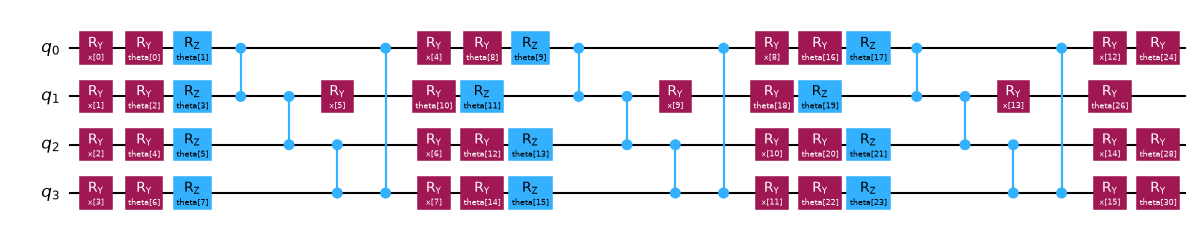

In [6]:
from qiskit.quantum_info import Statevector

from racetraq.agents.quantum.circuit import build_circuit, observables, split_parameters


def two_qubit_gates(circuit):
    return sum(1 for inst in circuit.data if inst.operation.num_qubits == 2)


def readouts(circuit, x_values, theta_values, n):
    inputs, weights = split_parameters(circuit)
    bound = circuit.assign_parameters(dict(zip(inputs + weights,
                                               [*x_values, *theta_values], strict=True)))
    state = Statevector(bound)
    return np.array([state.expectation_value(op).real for op in observables(n)[:4]])


print(f"{'qubits':>6}{'CZ full':>9}{'CZ pruned':>11}{'saved':>8}{'depth full':>12}"
      f"{'depth pruned':>14}{'max |<Z> full - pruned|':>26}")
RESULTS["cz"] = {}
for n in SIZES:
    full, pruned = build_circuit(n, LAYERS), lightcone.pruned_circuit(n, LAYERS)
    worst = 0.0
    for _ in range(3):  # random inputs and angles
        x = rng.uniform(-np.pi, np.pi, size=LAYERS * n)
        theta = rng.uniform(-np.pi, np.pi, size=LAYERS * n * 2)
        e_full = readouts(full, x, theta, n)
        e_pruned = readouts(pruned.circuit, x[pruned.input_index],
                            theta[pruned.weight_index], n)
        worst = max(worst, np.abs(e_full - e_pruned).max())
    assert worst < 1e-12
    cz_full, cz_pruned = two_qubit_gates(full), two_qubit_gates(pruned.circuit)
    RESULTS["cz"][n] = (cz_full, cz_pruned)
    print(f"{n:>6}{cz_full:>9}{cz_pruned:>11}{1 - cz_pruned / cz_full:>8.0%}"
          f"{full.depth():>12}{pruned.circuit.depth():>14}{worst:>26.1e}")

lightcone.pruned_circuit(4, LAYERS).circuit.draw("mpl", fold=30, scale=0.75)

The drawing is the 4-qubit circuit as it is actually sent to a backend: the
final CZ ring and the final RZ layer are gone. Those are logical gate counts;
what a device executes depends on its connectivity. The cell below transpiles
both versions for the local twin of the configured IBM device
(`[hardware] fake_name` — only its coupling map and native gates are used
here, nothing is simulated or submitted; skipped when `qiskit-ibm-runtime` is
not installed).

In [7]:
try:
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    from racetraq.hardware import get_backend

    device = get_backend(use_fake=True, fake_name=load_config()["hardware"]["fake_name"],
                         min_qubits=max(SIZES))
except Exception as exc:  # no qiskit-ibm-runtime, or an older one without this fake
    device = None
    print(f"skipped (no local device twin available): {exc}")

if device is not None:
    passes = generate_preset_pass_manager(optimization_level=2, backend=device,
                                          seed_transpiler=0)
    print(f"transpiled for {device.name} ({device.num_qubits} qubits), optimization level 2\n")
    print(f"{'qubits':>6}{'two-qubit gates full':>22}{'pruned':>8}{'depth full':>12}{'pruned':>8}")
    for n in SIZES:
        isa_full = passes.run(build_circuit(n, LAYERS))
        isa_pruned = passes.run(lightcone.pruned_circuit(n, LAYERS).circuit)
        print(f"{n:>6}{two_qubit_gates(isa_full):>22}{two_qubit_gates(isa_pruned):>8}"
              f"{isa_full.depth():>12}{isa_pruned.depth():>8}")

transpiled for fake_miami (120 qubits), optimization level 2

qubits  two-qubit gates full  pruned  depth full  pruned
     4                    16      12          44      39
     6                    24      17          52      43
     8                    32      20          60      41
    10                    40      21          68      36


If the transpiled two-qubit counts equal the logical ones, the ring was
embedded without SWAPs (a square lattice contains a ring of every even length
from 4 up; the shortest ring of a heavy-hex lattice has 12 qubits, so these
sizes have to be routed there). The hardware path
(`racetraq/hardware.py`, [notebook 05](05_real_quantum_hardware.ipynb)) uses
the pruned circuit by default.

The light cone has a second reading, which Part C returns to: a readout that
only depends on a bounded neighbourhood can also be *simulated* on that
neighbourhood alone.

## Part B — Classical surrogates: the Fourier picture of the trained driver

Feature $s_i$ enters the circuit only through the encoding gates
$RY(\lambda_{l,i}\,s_i)$, one per block. Conjugating any operator by
$RY(\varphi)$ yields a part constant in $\varphi$, a part $\propto\cos\varphi$
and a part $\propto\sin\varphi$ — nothing else. Every readout is therefore a
polynomial of degree one in $\big(1, \cos\lambda_{l,i}s_i, \sin\lambda_{l,i}s_i\big)$
for each encoding gate, i.e. a Fourier series

$$\langle Z_a\rangle(s) \;=\; \sum_{\omega\in\Omega_a} c_\omega\, e^{\,i\,\omega\cdot s},
\qquad \omega_i \;=\; \sum_{l} k_{l,i}\,\lambda_{l,i},\quad k_{l,i}\in\{-1,0,+1\},$$

with at most $3^L$ frequencies per feature
([Schuld, Sweke & Meyer 2021](https://arxiv.org/abs/2008.08605): the
frequencies are fixed by the data encoding, the circuit only chooses the
coefficients). Three things specific to this circuit:

- **the light cone prunes the spectrum** — an encoding gate outside readout
  $a$'s cone contributes no frequency, so the heat-maps of Part A are also
  maps of $\log_3$(frequencies per feature);
- **the spectrum is learned** — $\lambda$ is trainable. At initialisation
  every $\lambda = \pi$ and the sums collapse onto multiples of $\pi$; after
  training they are generic real numbers and (almost) all sums are distinct.
  Once training stops, though, the frequency set is fixed and *known*;
- **the product set is an upper bound** — it lists the frequencies the
  encoding gates *allow*. Which of them the circuit really uses is decided
  by everything else in it, and is counted below.

In [8]:
import json

config, q = load_driver("quantum_oval")
labels = action_labels(q.n_actions)
feature_names = CarObserver(oval_track, config).feature_names
untrained = QuantumQFunction(config["circuit"])  # every lam = pi

print(f"bundled oval driver: {q.n_qubits} qubits, {q.n_layers} blocks, "
      f"features {feature_names}")
sidecar = json.loads(drivers["quantum_oval"].path.with_suffix(".meta.json").read_text())
recipe = sidecar.get("selection", {}).get("overrides")  # on top of the default recipe
print("trained with: " + (", ".join(recipe) if recipe else "(not recorded)") + "\n")
print("trained input scalings lam[l, i] (rows = blocks, columns = features):")
print(np.array2string(q.lam, precision=2, suppress_small=True))

everything = surrogate.spectrum_size(q.lam)
print(f"\nfrequencies per feature, light cone ignored: {everything['per_feature']} "
      f"-> {everything['total']:,} frequency vectors")
print("inside each readout's light cone (still an upper bound: what the encoding allows):")
for a, name in enumerate(labels):
    size = surrogate.spectrum_size(q.lam, a)
    print(f"  {name:<9}<Z_{a}>: {size['live_gates']:>2} encoding gates, per feature "
          f"{size['per_feature']} -> {size['total']:,}")
before = surrogate.spectrum_size(untrained.lam, 0)
print(f"before training (all lam = pi), <Z_0>: per feature {before['per_feature']} "
      f"-> {before['total']:,}")
RESULTS["spectrum"] = surrogate.spectrum_size(q.lam, 0)["total"]

bundled oval driver: 4 qubits, 4 blocks, features ['ray -60°', 'ray 0°', 'ray +60°', 'speed']
trained with: training.bootstrap_truncation=true, training.action_gap=0.8, training.act_noise={attenuation=0.95,shots=1024}

trained input scalings lam[l, i] (rows = blocks, columns = features):
[[ 7.32  5.49  1.09  0.47]
 [ 4.28  3.37 -2.78  0.95]
 [ 5.52 -0.92  1.46  0.87]
 [ 4.89  5.43  0.02 -0.71]]

frequencies per feature, light cone ignored: [81, 81, 81, 81] -> 43,046,721 frequency vectors
inside each readout's light cone (still an upper bound: what the encoding allows):
  Right    <Z_0>: 12 encoding gates, per feature [81, 27, 9, 27] -> 531,441
  Straight <Z_1>: 12 encoding gates, per feature [27, 81, 27, 9] -> 531,441
  Left     <Z_2>: 12 encoding gates, per feature [9, 27, 81, 27] -> 531,441
  Brake    <Z_3>: 12 encoding gates, per feature [27, 9, 27, 81] -> 531,441
before training (all lam = pi), <Z_0>: per feature [9, 7, 5, 7] -> 2,205


### One slice, exactly

Hold all features but one at a typical driving state and sweep the remaining
one. Along that line the readout is a one-dimensional Fourier series with at
most $3^L$ terms, and its coefficients can be *computed* rather than fitted:
the circuit is of degree one in each encoding gate's angle separately, so
running it on a three-point grid per gate and taking a discrete Fourier
transform is exact (`surrogate.slice_coefficients`). Left: the circuit and its
series — extended beyond the physical range $[0,1]$ of a feature, where the
quasi-periodic structure shows. Right: which of the learned frequencies the
trained driver actually uses.

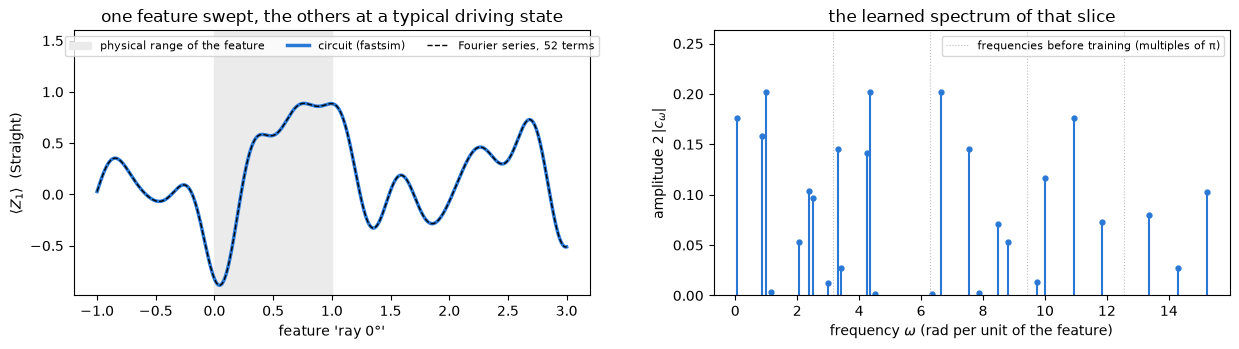

max |Fourier series - circuit| on the plotted range: 2.3e-15
terms with non-zero coefficient: 52 of 81 (3^L)
largest possible frequency per feature (sum_l |lam|): ray -60° 22.0, ray 0° 15.2, ray +60° 5.4, speed 3.0
-> at most 3.5 oscillations across the physical range of any feature


In [9]:
train_obs = surrogate.collect_observations(q, "oval", config, 4000, epsilon=0.1, seed=0)
test_obs = surrogate.collect_observations(q, "oval", config, 1000, epsilon=0.1, seed=999)
typical = np.median(train_obs, axis=0)

READOUT = 1  # "Straight"
FEATURE = feature_names.index("ray 0°") if "ray 0°" in feature_names else 1
k, omega, coef = surrogate.slice_coefficients(q.lam, q.theta, typical, FEATURE, READOUT)

x = np.linspace(-1.0, 3.0, 801)
obs = np.tile(typical, (x.size, 1))
obs[:, FEATURE] = x
circuit_values = q.expectations(obs)[:, READOUT]
series = (np.exp(1j * np.outer(x, omega)) @ coef).real
used = np.abs(coef) > 1e-12

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 3.6))
ax1.axvspan(0.0, 1.0, color="0.92", label="physical range of the feature")
ax1.plot(x, circuit_values, color=C_QUANTUM, lw=2.5, label="circuit (fastsim)")
ax1.plot(x, series, color="k", lw=1, ls="--", label=f"Fourier series, {used.sum()} terms")
ax1.set(xlabel=f"feature '{feature_names[FEATURE]}'",
        ylabel=rf"$\langle Z_{READOUT}\rangle$  ({labels[READOUT]})",
        title="one feature swept, the others at a typical driving state")
ax1.set_ylim(circuit_values.min() - 0.1, 1.6)
ax1.legend(fontsize=8, loc="upper center", ncol=3)

positive = used & (omega > 1e-9)
ax2.vlines(omega[positive], 0.0, 2 * np.abs(coef[positive]), color=C_QUANTUM, lw=1.5)
ax2.plot(omega[positive], 2 * np.abs(coef[positive]), "o", color=C_QUANTUM, ms=3.5)
for m in range(1, q.n_layers + 1):
    ax2.axvline(m * np.pi, color="0.75", lw=0.8, ls=":",
                label="frequencies before training (multiples of π)" if m == 1 else None)
ax2.set(xlabel=r"frequency $\omega$ (rad per unit of the feature)",
        ylabel=r"amplitude $2\,|c_\omega|$", title="the learned spectrum of that slice")
ax2.set_ylim(0.0, 1.3 * (2 * np.abs(coef[positive])).max())  # headroom for the legend
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

bandwidth = np.abs(q.lam).sum(axis=0)
assert np.abs(series - circuit_values).max() < 1e-9, "the Fourier series must be exact"
print(f"max |Fourier series - circuit| on the plotted range: "
      f"{np.abs(series - circuit_values).max():.1e}")
print(f"terms with non-zero coefficient: {used.sum()} of {coef.size} (3^L)")
print("largest possible frequency per feature (sum_l |lam|): "
      + ", ".join(f"{name} {b:.1f}" for name, b in zip(feature_names, bandwidth, strict=True)))
print(f"-> at most {bandwidth.max() / (2 * np.pi):.1f} oscillations across the physical "
      "range of any feature")
RESULTS["slice_error"] = float(np.abs(series - circuit_values).max())
RESULTS["oscillations"] = float(bandwidth.max() / (2 * np.pi))

The dashed series sits on the circuit to rounding error (the cell asserts
it) — the Fourier picture is not an approximation. Note the last printed
line, though: it says how many oscillations the fastest possible term
completes across the range a feature actually takes. When that number is
small, many of the frequencies are nearly indistinguishable on that range.
That will matter.

### How many of those frequencies are really there?

The slice has fewer non-zero terms than $3^L$ — a hint that the product set
over-counts. The same three-point trick works for *all* live encoding gates
of a readout at once (`surrogate.gate_coefficients`: $3^G$ simulator runs for
$G$ gates, affordable at 4 qubits). That gives every Fourier coefficient of
the real driver exactly — white-box, by running the simulator, not from
samples. Three things to check: does the full series reproduce the driver on
real driving states; how many of the allowed index vectors $k$ have a non-zero
coefficient, for the trained variational angles and for random ones; and how
many terms carry most of the Fourier weight $\sum_k |c_k|^2$?


In [10]:
READOUT_ALL = 0
try:
    gates, k_all, c_all = surrogate.gate_coefficients(q.theta, READOUT_ALL)
except ValueError as exc:  # a deeper retrained driver: 3^G runs are out of reach
    gates = None
    print(f"skipped: {exc}")

RESULTS["spectrum_used"] = None
if gates is not None:
    omega_all = np.zeros((k_all.shape[0], q.n_features))  # frequency vector of every k
    for g, (layer, i) in enumerate(gates):
        omega_all[:, i] += k_all[:, g] * q.lam[layer, i]
    present = np.abs(c_all) > 1e-12

    sample = test_obs[:25]
    full_series = (np.exp(1j * sample @ omega_all[present].T) @ c_all[present]).real
    series_error = np.abs(full_series - q.expectations(sample)[:, READOUT_ALL]).max()
    assert series_error < 1e-9, "the full Fourier series must reproduce the driver"

    random_theta = np.random.default_rng(2).uniform(-np.pi, np.pi, size=q.theta.shape)
    present_random = np.abs(surrogate.gate_coefficients(random_theta, READOUT_ALL)[2]) > 1e-12
    last_gate = np.flatnonzero((gates[:, 0] == q.n_layers - 1) & (gates[:, 1] == READOUT_ALL))[0]

    weight = np.sort(np.abs(c_all[1:]) ** 2)[::-1]  # k = 0, the constant term, left out
    cumulative = np.cumsum(weight) / weight.sum()
    shares = (0.9, 0.99, 0.999)
    carriers = [int(np.searchsorted(cumulative, share) + 1) for share in shares]

    print(f"<Z_{READOUT_ALL}> ({labels[READOUT_ALL]}) of the oval driver: {len(gates)} live "
          f"encoding gates, {c_all.size:,} index vectors k allowed")
    print(f"  full series vs circuit on {len(sample)} held-out driving states: "
          f"max error {series_error:.1e}")
    print(f"  non-zero coefficients: {present.sum():,} ({present.mean():.1%}) for the trained "
          f"angles, {present_random.sum():,} for random variational angles "
          f"({'the same' if np.array_equal(present, present_random) else 'not the same'} "
          "index vectors)")
    print("  ... with k = 0 on the measured qubit's last encoding gate: "
          f"{int(present[k_all[:, last_gate] == 0].sum())}")
    print("  terms carrying " + " / ".join(f"{share:.1%}" for share in shares)
          + " of the non-constant Fourier weight: " + " / ".join(f"{n:,}" for n in carriers))
    RESULTS["spectrum_used"] = int(present.sum())
    RESULTS["series_error"] = float(series_error)
    RESULTS["weight_carriers"] = dict(zip(shares, carriers, strict=True))


<Z_0> (Right) of the oval driver: 12 live encoding gates, 531,441 index vectors k allowed
  full series vs circuit on 25 held-out driving states: max error 2.3e-15
  non-zero coefficients: 45,072 (8.5%) for the trained angles, 45,072 for random variational angles (the same index vectors)
  ... with k = 0 on the measured qubit's last encoding gate: 0
  terms carrying 90.0% / 99.0% / 99.9% of the non-constant Fourier weight: 544 / 7,158 / 17,808


The full series is exact on real driving states (the cell asserts it), so
this *is* the driver. Two things to read off the counts. First, the product
spectrum is an **upper bound**: if the trained and the random angles leave
the same index vectors non-zero, the missing ones are ruled out by the fixed
structure of the circuit — the $|0\dots0\rangle$ input, the $Z$ readout,
which gate sits where — not by training. One such rule is easy to see by
hand: $RY(\varphi)$ turns $Z$ into $\cos\varphi\,Z - \sin\varphi\,X$, with no
constant part, so the measured qubit's last encoding gate always contributes
$\pm\lambda$, never $0$. Second, the last line: how unevenly the Fourier
weight is spread over the terms that survive. Counting *allowed* frequencies
can overstate the function on both counts; keep them in mind for "Why so
few?" below.

### From samples alone — exactly, on circuits small enough to afford it

If the frequencies are known, the circuit is a *linear* model in the basis
$\{\cos\omega\!\cdot\!s,\ \sin\omega\!\cdot\!s\}_{\omega\in\Omega_a}$ with unknown
coefficients, and least squares on input/output samples recovers it. This is
the check that the spectrum derivation (including the light-cone restriction)
is right: with *all* frequencies in the basis the fit must be exact.

In [11]:
rng = np.random.default_rng(1)
print(f"{'':<20}{'basis functions':>17}{'':>9}{'------ max |surrogate - circuit| ------':>44}")
print(f"{'circuit':<20}{'per readout':>17}{'samples':>9}{'true frequencies':>20}"
      f"{'every frequency x 1.3':>24}")
RESULTS["exact"] = {}
for n, layers in ((1, 2), (2, 2), (2, 3), (3, 2), (4, 2)):
    tiny = QuantumQFunction({"n_qubits": n, "n_layers": layers})
    tiny.lam = rng.uniform(1.0, 4.0, size=tiny.lam.shape)
    tiny.theta = rng.uniform(-3.0, 3.0, size=tiny.theta.shape)
    fit_x, check_x = rng.uniform(0.0, 3.0, size=(1500, n)), rng.uniform(0.0, 3.0, size=(500, n))
    exact = surrogate.fit_surrogate(tiny, fit_x, method="full", ridge=0.0)
    error = np.abs(exact.expectations(check_x) - tiny.expectations(check_x)).max()
    assert error < 1e-8, "the full spectrum must reproduce the circuit"
    # control: same samples, same number of basis functions, the wrong frequencies
    wrong = surrogate.FourierSurrogate(tiny.lam * 1.3, tiny.n_actions, method="full", ridge=0.0)
    wrong.fit(fit_x, tiny.expectations(fit_x))
    wrong_error = np.abs(wrong.expectations(check_x) - tiny.expectations(check_x)).max()
    RESULTS["exact"][(n, layers)] = (float(error), float(wrong_error))
    label = f"{n} qubit{'s' if n > 1 else ''}, {layers} blocks"
    print(f"{label:<20}"
          f"{surrogate.spectrum_size(tiny.lam, 0)['total']:>17}{fit_x.shape[0]:>9}"
          f"{error:>20.1e}{wrong_error:>24.1e}")
RESULTS["exact_error"] = max(error for error, _ in RESULTS["exact"].values())

try:
    surrogate.fit_surrogate(q, train_obs[:100], method="full", ridge=0.0)
except ValueError as exc:
    print(f"\nand the bundled driver? {exc}")

                      basis functions              ------ max |surrogate - circuit| ------
circuit                   per readout  samples    true frequencies   every frequency x 1.3
1 qubit, 2 blocks                   9     1500             2.8e-15                 8.1e-01
2 qubits, 2 blocks                  9     1500             2.7e-15                 4.6e-02
2 qubits, 3 blocks                 27     1500             5.0e-14                 1.3e-07
3 qubits, 2 blocks                 81     1500             4.8e-15                 1.7e+00
4 qubits, 2 blocks                 81     1500             5.4e-15                 1.1e+00

and the bundled driver? the full Fourier basis has 531441 functions (limit 20000); use method='rff' or 'kernel' for circuits of this size


Exact where it is affordable. The last column is a control: the same fit
(same samples, same number of basis functions) with the *wrong* frequencies,
every $\lambda$ scaled by 1.3. Compare the two error columns row by row. Where
a readout depends on several features, the wrong basis is nowhere near — the
exact fit is not just a flexible basis doing its job. The rows with one or two
qubits deserve a second look (there is no ring to speak of, so each readout
is a function of a *single* feature): the more sinusoids such a
one-dimensional basis has, the closer even the wrong frequencies come,
because on a bounded interval enough sinusoids of any frequencies approximate
a smooth function of one variable. Keep that in mind for "Why so few?" below.

For the real driver the full product basis is out of reach for a
least-squares fit — which is the usual argument for why such a model might
be hard to imitate classically. Two
standard ways around enumerating it:

- **Random Fourier features (RFF)** — draw $D$ frequency vectors at random
  from the spectrum (each $k_{l,i}$ independently), use their cos/sin as
  features, fit by ridge regression
  ([Landman et al., arXiv:2210.13200](https://arxiv.org/abs/2210.13200);
  conditions under which this provably works, and fails, for regression:
  [Sweke et al., Quantum 9, 1640 (2025)](https://quantum-journal.org/papers/q-2025-02-20-1640/),
  a collaboration including IBM Quantum authors).
- **Kernel ridge regression** — the $D\to\infty$ limit of those features is a
  kernel with a closed form, a product over the live encoding gates:
  $k_a(s,s') = \prod_{(l,i)} \tfrac13\big(1 + 2\cos\lambda_{l,i}(s_i - s'_i)\big)$.
  No frequency is ever enumerated.

Both need only **black-box samples** $(s, \langle Z\rangle(s))$ of the trained
model — one circuit evaluation per sample — plus the trained $\lambda$.

### Fitting the oval driver from samples

Where the samples come from matters. The natural choice is the states the car
actually visits: we let the quantum driver lap for a full episode with a
little exploration noise ($\varepsilon = 0.1$, so the log also covers the
neighbourhood of its line) and draw the samples at random from that driving
log (`surrogate.collect_observations`). The sample budget counts the labelled
states a fit uses; the log itself is a by-product of driving, since every
decision of the quantum driver evaluates the circuit anyway. The table scores
each surrogate on held-out driving states *and* on the uniform cube
$[0,1]^n$, where it has never seen a sample. Two controls get the same
samples: the same product kernel built from the *untrained* scalings (every
$\lambda = \pi$ — a kernel one could write down before any training), and a
kernel regression with a generic Gaussian kernel, which knows nothing about
the circuit at all. The last two rows are fitted on uniform samples of the
cube instead: the Fourier kernel and the Gaussian control again.

In [12]:
class GaussianControl:
    '''Kernel ridge regression with a generic Gaussian kernel (not tuned).'''

    def __init__(self, length=0.3, ridge=1e-6):
        self.length, self.ridge = length, ridge

    def _kernel(self, a, b):
        d2 = ((a[:, None, :] - b[None, :, :]) ** 2).sum(axis=-1)
        return np.exp(-d2 / (2 * self.length**2))

    def fit(self, obs, q_targets):
        self.x, self.mean = obs, q_targets.mean(axis=0)
        gram = self._kernel(obs, obs) + self.ridge * np.eye(obs.shape[0])
        self.coef = np.linalg.solve(gram, q_targets - self.mean)
        return self

    def q_values(self, obs):
        return self._kernel(np.asarray(obs, dtype=float), self.x) @ self.coef + self.mean


N_FIT = 1000
fit_obs = train_obs[:N_FIT]
cube_test = np.random.default_rng(5).uniform(0.0, 1.0, size=(1000, q.n_features))
cube_fit = np.random.default_rng(6).uniform(0.0, 1.0, size=(N_FIT, q.n_features))

models = {
    "kernel, driving samples": surrogate.fit_surrogate(q, fit_obs, method="kernel"),
    "RFF (256), driving samples": surrogate.fit_surrogate(
        q, fit_obs, method="rff", n_frequencies=256, seed=0),
    "kernel, untrained lam = pi": surrogate.fit_surrogate(
        q, fit_obs, lam=untrained.lam, method="kernel"),
    "generic Gaussian control": GaussianControl().fit(fit_obs, q.q_values(fit_obs)),
    "kernel, cube samples": surrogate.fit_surrogate(q, cube_fit, method="kernel"),
    "Gaussian, cube samples": GaussianControl().fit(cube_fit, q.q_values(cube_fit)),
}
kernel_surrogate = models["kernel, driving samples"]
rff_surrogate = models["RFF (256), driving samples"]

q_range = q.q_values(test_obs)
print(f"{N_FIT} samples each; Q-values of the quantum driver span "
      f"{q_range.min():.0f} .. {q_range.max():.0f} on its driving states\n")
print(f"{'':<28}{'------- held-out driving states -------':>42}"
      f"{'---------- uniform cube ----------':>38}")
print(f"{'model':<28}{'RMSE (Q)':>10}{'nRMSE':>8}{'same action':>13}{'gap-weighted':>13}"
      f"{'RMSE (Q)':>12}{'nRMSE':>8}{'same action':>13}")
RESULTS["fit"] = {}
for name, model in models.items():
    on, off = surrogate.compare(model, q, test_obs), surrogate.compare(model, q, cube_test)
    RESULTS["fit"][name] = (on, off)
    print(f"{name:<28}{on['rmse']:>10.3f}{on['nrmse']:>8.3f}{on['agreement']:>13.1%}"
          f"{on['gap_weighted_agreement']:>13.1%}"
          f"{off['rmse']:>12.3f}{off['nrmse']:>8.3f}{off['agreement']:>13.1%}")

1000 samples each; Q-values of the quantum driver span -12 .. 114 on its driving states

                               ------- held-out driving states -------    ---------- uniform cube ----------
model                         RMSE (Q)   nRMSE  same action gap-weighted    RMSE (Q)   nRMSE  same action


kernel, driving samples          1.285   0.082        99.9%       100.0%      24.604   0.799        68.4%
RFF (256), driving samples       1.112   0.071       100.0%       100.0%      23.547   0.765        65.6%


kernel, untrained lam = pi       1.400   0.090        99.9%       100.0%      28.954   0.940        53.3%
generic Gaussian control         1.681   0.108        99.8%        99.9%      37.046   1.203        60.2%


kernel, cube samples             0.395   0.025        96.0%        99.9%       0.190   0.006        99.9%
Gaussian, cube samples           6.316   0.405        67.3%        87.6%       7.531   0.245        91.1%


How to read the columns: **RMSE** is in Q-value units; **nRMSE** divides it by
the spread of the quantum driver's own Q-values on that set (1 = no better
than a constant). **Same action** is the fraction of states where surrogate
and circuit pick the same greedy action; **gap-weighted** weights each state
by the circuit's action gap (best minus second-best Q), so disagreeing where
the circuit itself barely has a preference counts little.

Four things to check in the output rather than take from this text: how
close the Fourier surrogates get on the states that matter for driving; how
much worse *every* model trained on driving states is on the cube (the
driving states are a thin slice of the cube, and because laps repeat, the
held-out ones lie close to the fitted ones — imitation is local); what the
trained frequencies are worth — the trained-$\lambda$ kernel against the
untrained-$\lambda$ kernel and the Gaussian control, on the driving states
and, for the two cube-fitted rows, on the cube; and whether the controls pick
the same actions even where their Q-values are visibly worse.

### Accuracy against the sample budget

Each point below is a fresh fit: three seeds per budget (new samples, new
random frequencies). Left and middle: trained and tested on driving states.
Right: trained and tested on the uniform cube — reproducing the function
*everywhere*, not just where the car goes.

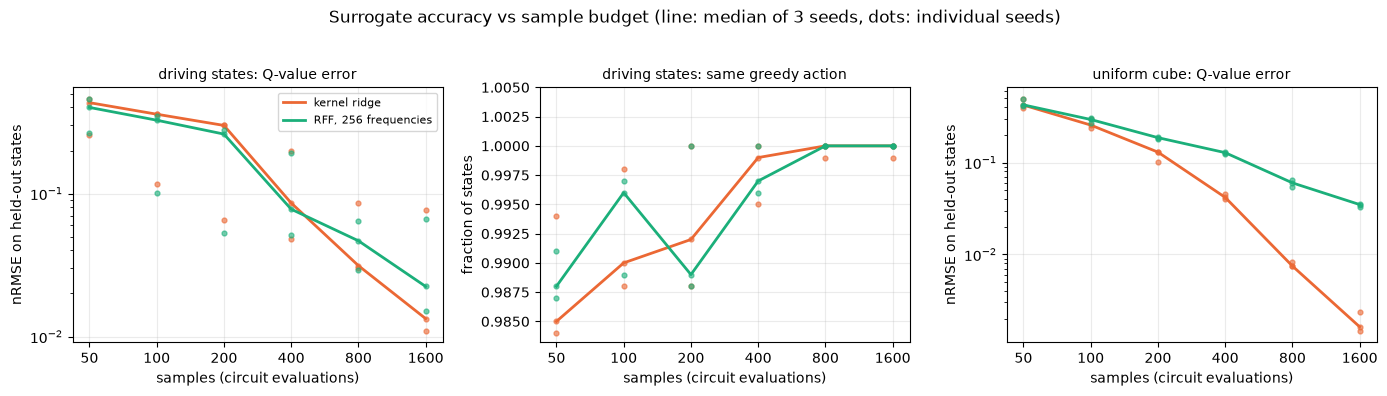

 samples       50      100      200      400      800     1600
driving, nRMSE (kernel)           0.432    0.359    0.300    0.086    0.031    0.013
driving, nRMSE (rff)              0.400    0.326    0.261    0.078    0.047    0.022
driving, same action (kernel)     0.985    0.990    0.992    0.999    1.000    1.000
driving, same action (rff)        0.988    0.996    0.989    0.997    1.000    1.000
cube, nRMSE (kernel)              0.422    0.256    0.130    0.042    0.007    0.002
cube, nRMSE (rff)                 0.424    0.294    0.186    0.128    0.060    0.035
cube, same action (kernel)        0.819    0.893    0.959    0.987    0.999    1.000
cube, same action (rff)           0.794    0.864    0.923    0.957    0.977    0.986

72 fits in 23 s


In [13]:
BUDGETS = (50, 100, 200, 400, 800, 1600)
SEEDS = (0, 1, 2)
METHODS = {"kernel": ({"method": "kernel"}, C_KERNEL, "kernel ridge"),
           "rff": ({"method": "rff", "n_frequencies": 256}, C_RFF, "RFF, 256 frequencies")}


def driving_pool(seed, cache={}):  # noqa: B006 - deliberate memo across cells
    if seed not in cache:
        cache[seed] = surrogate.collect_observations(q, "oval", config, max(BUDGETS), seed=seed)
    return cache[seed]


def cube_pool(seed):
    return np.random.default_rng(100 + seed).uniform(0.0, 1.0, size=(max(BUDGETS), q.n_features))


def budget_curves(pool, test):
    '''{method: array (seeds, budgets, 2)} of (nRMSE, greedy agreement).'''
    out = {name: np.zeros((len(SEEDS), len(BUDGETS), 2)) for name in METHODS}
    for i, seed in enumerate(SEEDS):
        samples = pool(seed)
        for j, budget in enumerate(BUDGETS):
            for name, (kwargs, _, _) in METHODS.items():
                fitted = surrogate.fit_surrogate(q, samples[:budget], seed=seed, **kwargs)
                score = surrogate.compare(fitted, q, test)
                out[name][i, j] = score["nrmse"], score["agreement"]
    return out


t0 = time.perf_counter()
on_track = budget_curves(driving_pool, test_obs)
on_cube = budget_curves(cube_pool, cube_test)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
panels = ((axes[0], on_track, 0, "driving states: Q-value error"),
          (axes[1], on_track, 1, "driving states: same greedy action"),
          (axes[2], on_cube, 0, "uniform cube: Q-value error"))
for ax, curves, metric, title in panels:
    for name, (_, color, label) in METHODS.items():
        values = curves[name][:, :, metric]
        ax.plot(BUDGETS, np.median(values, axis=0), color=color, lw=2, label=label)
        ax.plot(np.tile(BUDGETS, (len(SEEDS), 1)).T, values.T, "o", color=color, ms=3.5,
                alpha=0.6)
    ax.set_xscale("log")
    ax.set_xticks(BUDGETS)
    ax.set_xticklabels([str(b) for b in BUDGETS])
    ax.minorticks_off()
    ax.set_xlabel("samples (circuit evaluations)")
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.25)
    if metric == 0:
        ax.set_yscale("log")
        ax.set_ylabel("nRMSE on held-out states")
    else:
        ax.set_ylabel("fraction of states")
        ax.set_ylim(top=1.005)
axes[0].legend(fontsize=8)
fig.suptitle(f"Surrogate accuracy vs sample budget (line: median of {len(SEEDS)} seeds, "
             "dots: individual seeds)", y=1.03)
plt.tight_layout()
plt.show()

print(f"{'samples':>8}" + "".join(f"{b:>9}" for b in BUDGETS))
for title, curves, metric in (("driving, nRMSE", on_track, 0),
                              ("driving, same action", on_track, 1),
                              ("cube, nRMSE", on_cube, 0), ("cube, same action", on_cube, 1)):
    for name in METHODS:
        row = np.median(curves[name][:, :, metric], axis=0)
        print(f"{title + ' (' + name + ')':<30}" + "".join(f"{v:>9.3f}" for v in row))
print(f"\n{2 * len(SEEDS) * len(BUDGETS) * len(METHODS)} fits in {time.perf_counter() - t0:.0f} s")
RESULTS["budget"] = (on_track, on_cube)

### ... and against the number of random features

The same experiment along the other axis: a fixed budget of driving samples,
a growing number $D$ of random frequency vectors (each contributes a cosine
and a sine). The kernel fit is the $D\to\infty$ limit, drawn as a dashed line.

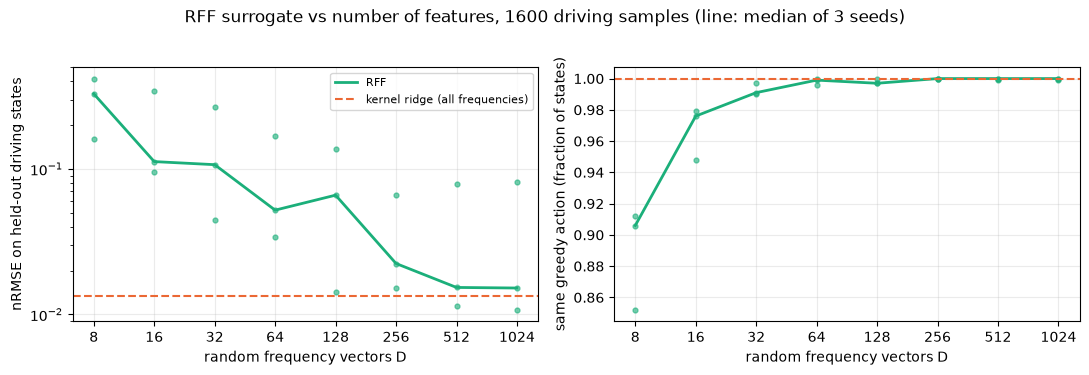

                     D       8      16      32      64     128     256     512    1024   kernel
        nRMSE (median)   0.328   0.112   0.107   0.052   0.066   0.022   0.015   0.015    0.013
  same action (median)   0.906   0.976   0.991   0.999   0.997   1.000   1.000   1.000    1.000
of 531,441 frequency vectors the encoding allows per readout (45,072 with a non-zero coefficient)


In [14]:
FEATURE_COUNTS = (8, 16, 32, 64, 128, 256, 512, 1024)
BUDGET_D = BUDGETS[-1]

by_features = np.zeros((len(SEEDS), len(FEATURE_COUNTS), 2))
for i, seed in enumerate(SEEDS):
    samples = driving_pool(seed)[:BUDGET_D]
    for j, count in enumerate(FEATURE_COUNTS):
        fitted = surrogate.fit_surrogate(q, samples, method="rff", n_frequencies=count, seed=seed)
        score = surrogate.compare(fitted, q, test_obs)
        by_features[i, j] = score["nrmse"], score["agreement"]
kernel_limit = np.median(on_track["kernel"][:, -1, :], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, metric, ylabel in ((axes[0], 0, "nRMSE on held-out driving states"),
                           (axes[1], 1, "same greedy action (fraction of states)")):
    ax.plot(FEATURE_COUNTS, np.median(by_features[:, :, metric], axis=0), color=C_RFF, lw=2,
            label="RFF")
    ax.plot(np.tile(FEATURE_COUNTS, (len(SEEDS), 1)).T, by_features[:, :, metric].T, "o",
            color=C_RFF, ms=3.5, alpha=0.6)
    ax.axhline(kernel_limit[metric], color=C_KERNEL, lw=1.5, ls="--",
               label="kernel ridge (all frequencies)")
    ax.set_xscale("log", base=2)
    ax.set_xticks(FEATURE_COUNTS)
    ax.set_xticklabels([str(c) for c in FEATURE_COUNTS])
    ax.set_xlabel("random frequency vectors D")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
axes[0].set_yscale("log")
axes[0].legend(fontsize=8)
fig.suptitle(f"RFF surrogate vs number of features, {BUDGET_D} driving samples "
             f"(line: median of {len(SEEDS)} seeds)", y=1.03)
plt.tight_layout()
plt.show()

print(f"{'D':>22}" + "".join(f"{c:>8}" for c in FEATURE_COUNTS) + f"{'kernel':>9}")
for label, metric in (("nRMSE (median)", 0), ("same action (median)", 1)):
    print(f"{label:>22}" + "".join(f"{v:>8.3f}" for v in np.median(by_features[:, :, metric], 0))
          + f"{kernel_limit[metric]:>9.3f}")
n_used = RESULTS["spectrum_used"]
print(f"of {RESULTS['spectrum']:,} frequency vectors the encoding allows per readout"
      + (f" ({n_used:,} with a non-zero coefficient)" if n_used else ""))

### Why so few? The spectrum is large, the function is not

Wherever the curves above reach small errors, they do so with sample budgets
and feature counts far below the number of allowed frequencies — and below
the number that really occur. One reason was counted above: how many terms
it takes to carry most of the Fourier weight. The other was visible in the
slice: when
the learned frequencies are small, many closely spaced frequencies on a
bounded interval are nearly the *same* function. Counting frequencies then
overstates the model; what counts is how many independent directions the
kernel has *on the data*. The eigenvalues of the matrix a
kernel fit solves measure that: a direction with eigenvalue $\mu$ is fitted
with weight $\mu/(\mu + \text{ridge})$, and the sum of those weights is the
regression's **effective dimension** — the number of directions it actually
resolves.

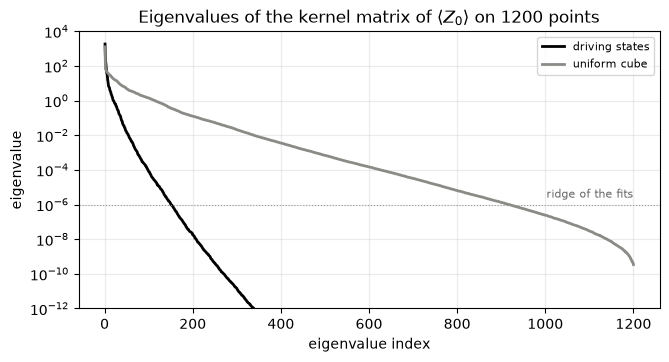

effective dimension at ridge 1e-06 (the encoding allows 531,441 frequency vectors)

  points    driving states      uniform cube
     300                91               300
     600               117               583
    1200               151               912


In [15]:
N_EIG = (300, 600, 1200)
RIDGE = kernel_surrogate.ridge  # the ridge of the kernel fits above
eig_sources = {"driving states": train_obs, "uniform cube": cube_pool(0)}


def gram_eigenvalues(points, readout=0):
    '''Eigenvalues, largest first, of the matrix the kernel fit of one readout solves.'''
    mask = surrogate.encoding_mask(q.n_qubits, q.n_layers, readout)
    gram = surrogate.product_kernel(points, points, q.lam, mask) + 1.0  # + the constant
    return np.clip(np.linalg.eigvalsh(gram)[::-1], 0.0, None)


def effective_dimension(eig, ridge=RIDGE):
    return float((eig / (eig + ridge)).sum())


eigenvalues = {name: {n: gram_eigenvalues(points[:n]) for n in N_EIG}
               for name, points in eig_sources.items()}

fig, ax = plt.subplots(figsize=(7.5, 3.6))
for (name, by_n), color in zip(eigenvalues.items(), ("k", C_GENERIC), strict=True):
    eig = by_n[N_EIG[-1]]
    ax.plot(np.arange(1, eig.size + 1), np.clip(eig, 1e-18, None), color=color, lw=2, label=name)
ax.axhline(RIDGE, color="0.6", lw=0.8, ls=":")
ax.text(N_EIG[-1], RIDGE * 2.5, "ridge of the fits", ha="right", fontsize=8, color="0.4")
ax.set(yscale="log", ylim=(1e-12, 1e4), xlabel="eigenvalue index", ylabel="eigenvalue",
       title=rf"Eigenvalues of the kernel matrix of $\langle Z_0\rangle$ on {N_EIG[-1]} points")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.show()

print(f"effective dimension at ridge {RIDGE:.0e} (the encoding allows "
      f"{RESULTS['spectrum']:,} frequency vectors)\n")
print(f"{'points':>8}" + "".join(f"{name:>18}" for name in eigenvalues))
for n in N_EIG:
    print(f"{n:>8}" + "".join(f"{effective_dimension(by_n[n]):>18.0f}"
                              for by_n in eigenvalues.values()))
RESULTS["effective"] = {name: effective_dimension(by_n[N_EIG[-1]])
                        for name, by_n in eigenvalues.items()}

The effective dimension belongs to the kernel, the points and the ridge
together, not to the circuit alone: it can never exceed the number of points
(where it comes close, read it as "at least"), and the table shows how fast
it still grows as points are added. Compare it with the number of
frequencies, and compare the driving states with the cube. When it is small,
few samples and few random features are enough — the regime the curves above
are in. A model escapes it only if its Fourier weight is spread over so many
well-separated frequencies that no modest sample of them captures it
(Part C).

### The test that matters: let the surrogate drive

Agreement on held-out states is a proxy. The real test puts the classical
surrogate in the driver's seat: the standard 36-episode greedy evaluation of
`racetraq.records` (standing starts with distinct seeded start jitter;
`surrogate.drive_laps`), same episodes for every driver. Small Q-value errors
can compound — one different action leads to states the quantum driver never
visited — so this is where an imitator gets found out.

In [16]:
EPISODES = 36


def lap_row(label, policy, track, cfg):
    t0 = time.perf_counter()
    result = surrogate.drive_laps(policy, track, cfg, episodes=EPISODES)
    result["wall_s"] = time.perf_counter() - t0
    mean = f"{result['mean_s']:.2f} s" if result["laps"] else "-"
    best = f"{result['best_s']:.1f} s" if result["laps"] else "-"
    print(f"  {label:<32}{result['lapped_episodes']:>3}/{EPISODES:<4}{result['laps']:>6}"
          f"{mean:>11}{best:>9}{result['crashed']:>9}{result['wall_s']:>8.1f} s")
    return result


def header(title):
    print(f"{title}\n  {'driver':<32}{'lapped':>8}{'laps':>6}{'mean lap':>11}{'best':>9}"
          f"{'crashed':>9}{'wall':>10}")


header(f"oval, {q.n_qubits} qubits - {EPISODES} greedy episodes each")
oval_laps = {"quantum": lap_row("quantum circuit (fastsim)", q, "oval", config)}
for name, model in models.items():
    oval_laps[name] = lap_row(name, model, "oval", config)
RESULTS["oval_laps"] = oval_laps

oval, 4 qubits - 36 greedy episodes each
  driver                            lapped  laps   mean lap     best  crashed      wall


  quantum circuit (fastsim)        36/36     144    12.66 s   12.1 s        0     3.1 s


  kernel, driving samples          36/36     144    12.66 s   12.1 s        0     7.5 s


  RFF (256), driving samples       36/36     144    12.66 s   12.1 s        0     3.2 s


  kernel, untrained lam = pi       36/36     144    12.66 s   12.1 s        0     7.7 s


  generic Gaussian control         36/36     144    12.65 s   12.1 s        0     3.4 s


  kernel, cube samples             36/36     144    12.62 s   12.1 s        0     7.4 s


  Gaussian, cube samples            0/36       0          -        -       36     0.4 s


*Lapped* = episodes with at least one completed lap; *crashed* = episodes that
ended off track (possibly after several laps). Compare each classical row
with the quantum row — and note which rows you would *not* have predicted
from the accuracy table. Each row is a single fit, so read it as an example,
not as a rate. Two readings to keep apart. Where a model that knows nothing
about the circuit, or one built from the untrained $\lambda$, laps like the
quantum driver, lapping the oval is a low bar — which says more about the
task than about any of the models. And where a row fails outright, look up
its accuracy *on the driving states* in the table above: a model fitted on
the cube drives only as well as it is accurate where the car actually goes.

The same experiment on harder ground, with fresh surrogates fitted from each
driver's own driving states: the 4-qubit gp driver (hairpin, braking), and a
6-qubit driver. A track is skipped if the bundled quantum driver itself does
not lap it. The gp block ends with a deliberately badly sampled surrogate:
the same budget, but every sample from the first seconds after the start.
Check its two agreement figures against its laps — an accuracy number is only
as good as the states it was measured on.

In [17]:
def imitate(driver_id, track, n_fit=1000, n_frequencies=256, start_only=False):
    '''Fit kernel + RFF surrogates of a bundled driver on `track` and race all three.'''
    if driver_id not in drivers:
        print(f"{driver_id}: not bundled - skipped\n")
        return None
    cfg, qd = load_driver(driver_id)
    header(f"{track}, {qd.n_qubits} qubits ({driver_id}) - {EPISODES} greedy episodes each")
    out = {"quantum": lap_row("quantum circuit (fastsim)", qd, track, cfg)}
    if out["quantum"]["lapped_episodes"] == 0:
        print("  the bundled quantum driver does not lap here - nothing to imitate\n")
        return out
    states = surrogate.collect_observations(qd, track, cfg, n_fit, epsilon=0.1, seed=0)
    held_out = surrogate.collect_observations(qd, track, cfg, 1000, epsilon=0.1, seed=999)
    out["models"], out["other_seeds"] = {}, {}
    methods = (("kernel", {"method": "kernel"}),
               ("rff", {"method": "rff", "n_frequencies": n_frequencies}))
    for name, kwargs in methods:
        fitted = surrogate.fit_surrogate(qd, states, seed=0, **kwargs)
        score = surrogate.compare(fitted, qd, held_out)
        out[name] = lap_row(f"{name} surrogate ({n_fit} samples)", fitted, track, cfg)
        out[name]["score"] = score
        out["models"][name] = fitted
    spectrum = surrogate.spectrum_size(qd.lam, 0)["total"]
    print(f"  frequency vectors allowed per readout: {spectrum:,}; held-out driving states: "
          + ", ".join(f"{name} nRMSE {out[name]['score']['nrmse']:.3f} / same action "
                      f"{out[name]['score']['agreement']:.1%}" for name in ("kernel", "rff")))
    for seed in SEEDS[1:]:  # the rows above are single fits: repeat with other seeds
        again = surrogate.collect_observations(qd, track, cfg, n_fit, epsilon=0.1, seed=seed)
        for name, kwargs in methods:
            refit = surrogate.fit_surrogate(qd, again, seed=seed, **kwargs)
            out["other_seeds"].setdefault(name, []).append(
                surrogate.drive_laps(refit, track, cfg, episodes=EPISODES)["lapped_episodes"])
    print(f"  refitted with other sample/frequency seeds {SEEDS[1:]}, episodes lapped: "
          + "; ".join(f"{name} " + ", ".join(f"{count}/{EPISODES}" for count in counts)
                      for name, counts in out["other_seeds"].items()))
    if start_only:  # the same budget, all of it from the first seconds after the start
        short = {"epsilon": 0.1, "decisions": n_fit // 16}
        early = surrogate.collect_observations(qd, track, cfg, n_fit, seed=0, **short)
        early_test = surrogate.collect_observations(qd, track, cfg, n_fit, seed=999, **short)
        fitted = surrogate.fit_surrogate(qd, early, method="kernel")
        out["start-only"] = lap_row("kernel, start-only samples", fitted, track, cfg)
        print(f"  start-only surrogate, same action as the circuit: "
              f"{surrogate.compare(fitted, qd, early_test)['agreement']:.1%} on held-out "
              f"start-only states, {surrogate.compare(fitted, qd, held_out)['agreement']:.1%} "
              "on held-out states from whole laps")
    print()
    return out


RESULTS["gp_laps"] = imitate("quantum_gp", "gp", start_only=True)
RESULTS["q6_laps"] = imitate("quantum_oval_q6", "oval")

gp, 4 qubits (quantum_gp) - 36 greedy episodes each
  driver                            lapped  laps   mean lap     best  crashed      wall


  quantum circuit (fastsim)        36/36      72    27.93 s   26.8 s        0     3.3 s


  kernel surrogate (1000 samples)  36/36      72    27.92 s   26.7 s        0     8.2 s


  rff surrogate (1000 samples)     36/36      72    27.93 s   26.6 s        0     3.5 s
  frequency vectors allowed per readout: 531,441; held-out driving states: kernel nRMSE 0.005 / same action 99.8%, rff nRMSE 0.007 / same action 99.6%


  refitted with other sample/frequency seeds (1, 2), episodes lapped: kernel 36/36, 36/36; rff 36/36, 36/36


...

  start-only surrogate, same action as the circuit: 100.0% on held-out start-only states, 96.4% on held-out states from whole laps

oval, 6 qubits (quantum_oval_q6) - 36 greedy episodes each
  driver                            lapped  laps   mean lap     best  crashed      wall


  quantum circuit (fastsim)        36/36     144    13.06 s   12.5 s        0     5.5 s


  kernel surrogate (1000 samples)  36/36     144    13.06 s   12.6 s        0     9.0 s


  rff surrogate (1000 samples)     36/36     144    13.06 s   12.5 s        0     5.1 s
  frequency vectors allowed per readout: 14,348,907; held-out driving states: kernel nRMSE 0.205 / same action 100.0%, rff nRMSE 0.174 / same action 99.6%


  refitted with other sample/frequency seeds (1, 2), episodes lapped: kernel 36/36, 36/36; rff 36/36, 36/36



Each surrogate row is a single fit; the "refitted" line repeats it with
other sample and frequency seeds and reports the lapped episodes only. Read
that spread before reading anything into a difference of an episode or two —
and note whether one method is consistently behind the quantum driver.

Read the accuracy line of the 6-qubit block next to the 4-qubit ones: the
same sample budget against a larger spectrum. Where the Q-value error is
visibly larger and the laps are still there, that is once more a statement
about how forgiving the task is.

One lap, drawn: the quantum driver and its kernel surrogate from the same
standing start, on the hardest track above that the quantum driver laps. If
the two ever choose differently the paths separate from there on (a greedy
policy has no way back to the other's trajectory).

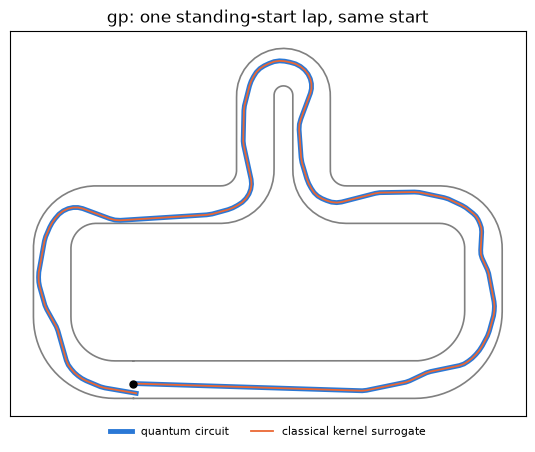

quantum:   lap in 28.6 s
surrogate: lap in 28.6 s
first decision where the two choose differently: none in 286 decisions


In [18]:
def trace(policy, track, cfg, seed=3, max_steps=600):
    '''Positions and actions of one greedy standing-start episode, up to its first lap.'''
    env = RacingEnv(track, cfg, n_envs=1, seed=seed)
    obs, path, actions = env.reset(), [env.state[0, :2].copy()], []
    for _ in range(max_steps):
        action = np.argmax(policy.q_values(obs), axis=1)
        obs, _, done, info = env.step(action)
        actions.append(int(action[0]))
        if not done[0]:  # a finished episode has already respawned at the start
            path.append(env.state[0, :2].copy())
        if done[0] or info["lap"][0] >= 1:
            break
    lap_s = float(info["last_lap_time"][0]) if info["lap"][0] >= 1 else None
    return np.array(path), np.array(actions), lap_s


gp_result = RESULTS["gp_laps"]
if gp_result and "models" in gp_result:
    trace_id, trace_track, trace_model = "quantum_gp", "gp", gp_result["models"]["kernel"]
else:
    trace_id, trace_track, trace_model = "quantum_oval", "oval", kernel_surrogate
trace_cfg, trace_q = load_driver(trace_id)
track_obj = Track.load(trace_track, trace_cfg["track"]["resample_spacing"])
path_q, actions_q, lap_q = trace(trace_q, track_obj, trace_cfg)
path_s, actions_s, lap_s = trace(trace_model, track_obj, trace_cfg)

fig, ax = plt.subplots(figsize=(7, 5))
for sign in (+1.0, -1.0):
    edge = track_obj.centerline + sign * track_obj.half_width * track_obj.normals
    edge = np.vstack([edge, edge[:1]])
    ax.plot(edge[:, 0], edge[:, 1], color="0.5", lw=1.2)
ax.plot(path_q[:, 0], path_q[:, 1], color=C_QUANTUM, lw=3.5, label="quantum circuit")
ax.plot(path_s[:, 0], path_s[:, 1], color=C_KERNEL, lw=1.3, label="classical kernel surrogate")
ax.plot(*path_q[0], "o", color="k", ms=5)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"{trace_track}: one standing-start lap, same start")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False)
plt.show()

common = min(actions_q.size, actions_s.size)
differ = np.flatnonzero(actions_q[:common] != actions_s[:common])


def outcome(lap, actions):
    return f"lap in {lap:.1f} s" if lap is not None else f"off track after {actions.size} decisions"


print(f"quantum:   {outcome(lap_q, actions_q)}")
print(f"surrogate: {outcome(lap_s, actions_s)}")
print("first decision where the two choose differently: "
      + (f"#{differ[0]} of {common}" if differ.size else f"none in {common} decisions"))

### Surrogates from noisy samples

On hardware the samples are not exact: each $\langle Z_a\rangle$ is an average
over shots. Nothing in the fit changes — `fit_surrogate` takes any callable —
except that the ridge now has a job: too small and the surrogate memorises
the shot noise. Below, the samples are simulated shot estimates of the oval
driver (`surrogate.ShotNoisePolicy`; binomial sampling, no device noise), and
the ridge is chosen the way one would have to on a device: by the error
against *other noisy samples*, never against exact values. The last columns
then reveal the truth.

In [19]:
SHOTS = 1024
noisy = surrogate.ShotNoisePolicy(q, shots=SHOTS, seed=1)
fit_x, val_x = train_obs[:2000], train_obs[2000:3000]
fit_y, val_y = noisy.expectations(fit_x), noisy.expectations(val_x)  # what a sampler returns

print(f"{fit_x.shape[0]} samples at {SHOTS} shots; RFF surrogate, 256 frequencies\n")
print(f"{'ridge':>8}{'RMSE vs noisy validation':>27}{'true RMSE of <Z>':>19}{'same action':>14}")
candidates = []
for ridge in (1e-6, 1e-4, 1e-2, 1.0):
    fitted = surrogate.FourierSurrogate(q.lam, q.n_actions, method="rff", n_frequencies=256,
                                        ridge=ridge, head=(q.w, q.b), seed=0).fit(fit_x, fit_y)
    validation = float(np.sqrt(np.mean((fitted.expectations(val_x) - val_y) ** 2)))
    truth = surrogate.compare(fitted, q, test_obs)
    candidates.append((validation, ridge, truth))
    print(f"{ridge:>8.0e}{validation:>27.4f}{truth['rmse_expectation']:>19.4f}"
          f"{truth['agreement']:>14.1%}")
_, chosen_ridge, chosen = min(candidates, key=lambda c: c[0])
raw = surrogate.compare(noisy, q, test_obs)
print(f"\nchosen by validation: ridge = {chosen_ridge:.0e}")
print(f"{'one noisy evaluation of the circuit itself':<46}"
      f"true RMSE of <Z> {raw['rmse_expectation']:.4f}, same action {raw['agreement']:.1%}")
print(f"{'surrogate fitted to noisy samples':<46}"
      f"true RMSE of <Z> {chosen['rmse_expectation']:.4f}, same action {chosen['agreement']:.1%}")
RESULTS["noise"] = (raw, chosen)

2000 samples at 1024 shots; RFF surrogate, 256 frequencies

   ridge   RMSE vs noisy validation   true RMSE of <Z>   same action


   1e-06                     0.0889             0.1289         98.4%


   1e-04                     0.0229             0.0141         99.6%


   1e-02                     0.0203             0.0095         99.4%


   1e+00                     0.0314             0.0309         98.3%

chosen by validation: ridge = 1e-02
one noisy evaluation of the circuit itself    true RMSE of <Z> 0.0175, same action 93.2%
surrogate fitted to noisy samples             true RMSE of <Z> 0.0095, same action 99.4%


Compare the last two lines. A regression over many noisy samples averages
their noise, so the surrogate can be *closer to the exact circuit than a
single shot-limited evaluation of that circuit* — in which case, for
inference, the classical copy is the better driver of the two. (Shot noise
only: device noise would bias the samples, and the surrogate would faithfully
learn the biased function.) How often one shot-limited evaluation picks the
exact action is a property of the driver as much as of the shot count: it
depends on how far apart the Q-values of the best and the second-best action
are. The "trained with" line under the driver above says whether its recipe
was meant to widen that gap (`action_gap`, `act_noise`);
[notebook 05](05_real_quantum_hardware.ipynb) measures the effect.

## Part C — What this does, and does not, mean

Same rule as every notebook here: being honest matters more than being
exciting. The summary cell below collects the measured numbers; this is how to
read them.

**1. Nothing here was hard for a classical computer in the first place.**
An $n$-qubit statevector is $2^n$ complex numbers — tiny at these sizes —
and the drivers were *trained* on a numpy simulation of the circuit. The
surrogate does not make the circuit classically tractable — it already was.
What Part B shows is narrower and
more structural: the *function* the trained circuit computes is a Fourier
series with known frequencies, which a classical regression can pick up from
samples without knowing anything about qubits.

**2. The surrogate dequantizes inference, not training.** It used two
things that exist only *after* quantum training: the trained input scalings
$\lambda$ (they fix the frequencies) and query access to the trained model
(the samples). The control rows say what each was worth: without the samples
there is nothing to fit, whereas the trained $\lambda$ is worth whatever
accuracy separates the trained-$\lambda$ kernel from the untrained-$\lambda$
one — and, wherever the controls also lap, was not needed to drive. That is
exactly the "classical surrogate" of
[Schreiber, Eisert & Meyer (2023)](https://arxiv.org/abs/2206.11740): a
classical model obtained from a trained quantum model that reproduces its
input–output relation, so that inference no longer needs the quantum device.
It says nothing about whether a classical learner could have *found* a
driver this good with the same data and effort — that comparison (against a
small MLP trained from scratch) is
[notebook 04](04_training_the_quantum_driver.ipynb)'s.

**3. Imitating the driver is not the same as reproducing the function — and
neither needs the full spectrum.** The budget curves show what each costs:
matching the circuit on the states the car visits, and matching it on the
whole cube. Neither budget is anywhere near the number of allowed
frequencies — itself an over-count of what the circuit uses; the kernel's
effective dimension on those states (the eigenvalue table) is the more
relevant scale. And the
generic control is a warning against over-reading a lap: if a regression that
knows nothing about the circuit also drives, then a lap by the Fourier
surrogate is evidence that the *policy* is simple, not evidence for the
Fourier picture. The evidence for the Fourier picture is the exact
reproduction — on small circuits from samples, and of the real driver by its
full series. What the true frequencies then *buy* a fit from a limited
sample is a separate, measured question: the summary cell lists every
model's Q-value error next to its laps, on the driving states and on the
cube. Read the trained-$\lambda$ rows against the controls in both columns
— the two need not tell the same story.

**4. Training is the harder part, and it is being worked on.**
Schreiber, Eisert & Meyer already note that the surrogate's own ansatz can be
optimised directly, which makes it a classical benchmark a quantum model has
to outperform. For supervised regression this goes further:
[Landman et al.](https://arxiv.org/abs/2210.13200) build their random-feature
approximation from the description of the circuit's architecture alone, and
[Sweke et al. (2025)](https://quantum-journal.org/papers/q-2025-02-20-1640/)
give necessary and sufficient conditions under which random Fourier features
efficiently dequantize variational quantum machine learning for regression —
the learning problem, not only a trained model. For reinforcement learning,
[Rodriguez-Grasa, Jerbi, Sanz & Sweke, *Towards Surrogate Based Dequantization
of Quantum Reinforcement Learning* (arXiv:2609.16266, September 2026)](https://arxiv.org/abs/2609.16266)
take steps towards dequantizing quantum Q-learning itself. In a simplified
setting — a uniform generative model, i.e. uniformly random state–action
samples, modelling a large replay buffer after sufficient exploration — they
give finite-sample
guarantees for classical **kernelized fitted Q-iteration** with kernels
designed to match the inductive bias of particular parameterized circuits,
and sufficient conditions (on the data-encoding strategy, the kernel and the
problem structure) under which this is a meaningful dequantization of quantum
Q-learning; where the conditions cannot be verified they propose it as a
heuristic. We did **not** run fitted Q-iteration here. The product kernel of
Part B is the natural candidate for it, with one caveat that is specific to
circuits like ours: the input scaling is *trainable*, so the kernel is not
known before training — ours was built from the trained $\lambda$. A
classical learner that wants to skip the quantum training has to choose its
own frequencies (a bandwidth, in effect), which is ordinary model selection,
not a quantum resource.

**5. The light cone is a simulability statement too.** A readout that
depends only on a bounded neighbourhood can be simulated on that
neighbourhood alone. At a fixed number of blocks the neighbourhood stops
growing with the register (summary cell), so widening this circuit never
makes a single readout harder to simulate classically — only deepening it
with the width does.

**6. What would have to be true for a quantum model to escape this?**
Roughly, all of the following at once:

- *Not directly simulable*: light cones and entanglement that grow with the
  problem size (depth growing with width; no small neighbourhood per readout).
- *Not surrogate-able*: a spectrum that is not just large but whose weight is
  spread so that no efficiently sampled set of frequencies captures it, with
  an effective dimension that grows too fast for kernel methods —
  [Sweke et al. (2025)](https://quantum-journal.org/papers/q-2025-02-20-1640/)
  make this precise for regression, giving necessary and sufficient
  conditions for RFF dequantization, and
  [Landman et al.](https://arxiv.org/abs/2210.13200) expect complex encodings
  and large input dimension to be the robust cases.
- *Still trainable*: [Cerezo et al., Nat. Commun. 16, 7907 (2025)](https://doi.org/10.1038/s41467-025-63099-6)
  — a perspective article — collect evidence, case by case, that the
  structure which lets many common models provably avoid barren plateaus
  also confines them to small, classically simulable subspaces, possibly
  after an initial data-acquisition phase on a quantum device (loosely the
  shape of Part B: query the quantum model first, compute classically
  afterwards). They list caveats themselves, among them smart
  initialisations and models outside their assumptions.
- *Needed by the task*: the problem must have structure that such a model
  captures and classical models of comparable cost do not. A racing policy
  that a small classical network also learns is not that problem.

None of these holds for racetraQ, by design: it is a transparent,
fully-inspectable teaching testbed, and no quantum advantage is claimed.

In [20]:
def ratio(result):
    return f"{result['lapped_episodes']}/{result['episodes']} episodes lapped" + (
        f", mean lap {result['mean_s']:.2f} s" if result["laps"] else "")


on, off = RESULTS["fit"]["kernel, driving samples"]
print("light cones")
print(f"  dead circuit parameters at L = {LAYERS}: "
      + ", ".join(f"{dead} at {n} qubits" for n, dead in RESULTS["dead"].items()))
print("  CZ gates full -> pruned: "
      + ", ".join(f"{full} -> {pruned} ({n}q)" for n, (full, pruned) in RESULTS["cz"].items()))
widths = {n: int(lightcone.readout_live_gates(n, LAYERS, 0)["enc"].any(axis=0).sum())
          for n in (*SIZES, 20, 100)}
print(f"  qubits a single readout depends on at L = {LAYERS}: "
      + ", ".join(f"{w} of {n}" for n, w in widths.items()))

print("\nthe Fourier picture")
print(f"  exact slice: max error {RESULTS['slice_error']:.0e}; full-basis fits of "
      f"{len(RESULTS['exact'])} small circuits: max error {RESULTS['exact_error']:.0e}")
print(f"  frequency vectors the encoding allows per readout of the oval driver: "
      f"{RESULTS['spectrum']:,}"
      + (f"; with a non-zero coefficient: {RESULTS['spectrum_used']:,} (full series exact to "
         f"{RESULTS['series_error']:.0e})" if RESULTS["spectrum_used"] else ""))
print(f"  effective dimension of a kernel fit on {N_EIG[-1]} points at ridge {RIDGE:.0e}: "
      + ", ".join(f"{count:.0f} ({name})" for name, count in RESULTS["effective"].items()))
print(f"  fastest learned frequency: {RESULTS['oscillations']:.1f} oscillations across a "
      "feature's range")

print(f"\nsurrogates of the oval driver ({N_FIT} samples)")
print(f"  kernel surrogate on driving states: nRMSE {on['nrmse']:.3f}, same greedy action "
      f"{on['agreement']:.1%} (gap-weighted {on['gap_weighted_agreement']:.1%}); "
      f"on the cube: nRMSE {off['nrmse']:.3f}")
print("  laps, and nRMSE of the fit on driving states / on the cube:")
for name, result in RESULTS["oval_laps"].items():
    fit = RESULTS["fit"].get(name)  # none for the quantum driver itself
    accuracy = f"; nRMSE {fit[0]['nrmse']:.3f} / {fit[1]['nrmse']:.3f}" if fit else ""
    print(f"  {name:<28}{ratio(result)}{accuracy}")
for key, title in (("gp_laps", "gp, 4 qubits"), ("q6_laps", "oval, 6 qubits")):
    result = RESULTS[key]
    if result:
        print(f"{title}")
        for name in ("quantum", "kernel", "rff", "start-only"):
            if name in result:
                others = result.get("other_seeds", {}).get(name)
                print(f"  {name:<28}{ratio(result[name])}" + (
                    f" (other seeds: {', '.join(str(count) for count in others)} lapped)"
                    if others else ""))
raw, chosen = RESULTS["noise"]
print(f"\n{SHOTS}-shot samples: one noisy circuit evaluation picks the exact circuit's action "
      f"{raw['agreement']:.1%} of the time,\n  a surrogate fitted to such samples "
      f"{chosen['agreement']:.1%}")
print(f"\nnotebook runtime: {time.perf_counter() - T_START:.0f} s")

light cones
  dead circuit parameters at L = 4: 4 at 4 qubits, 12 at 6 qubits, 26 at 8 qubits, 46 at 10 qubits
  CZ gates full -> pruned: 16 -> 12 (4q), 24 -> 17 (6q), 32 -> 20 (8q), 40 -> 21 (10q)
  qubits a single readout depends on at L = 4: 4 of 4, 6 of 6, 7 of 8, 7 of 10, 7 of 20, 7 of 100

the Fourier picture
  exact slice: max error 2e-15; full-basis fits of 5 small circuits: max error 5e-14
  frequency vectors the encoding allows per readout of the oval driver: 531,441; with a non-zero coefficient: 45,072 (full series exact to 2e-15)
  effective dimension of a kernel fit on 1200 points at ridge 1e-06: 151 (driving states), 912 (uniform cube)
  fastest learned frequency: 3.5 oscillations across a feature's range

surrogates of the oval driver (1000 samples)
  kernel surrogate on driving states: nRMSE 0.082, same greedy action 99.9% (gap-weighted 100.0%); on the cube: nRMSE 0.799
  laps, and nRMSE of the fit on driving states / on the cube:
  quantum                     36/36 epi

## References

1. M. Schuld, R. Sweke, J. J. Meyer, *Effect of data encoding on the
   expressive power of variational quantum machine learning models*,
   Phys. Rev. A 103, 032430 (2021). <https://arxiv.org/abs/2008.08605>
2. F. J. Schreiber, J. Eisert, J. J. Meyer, *Classical surrogates for quantum
   learning models*, Phys. Rev. Lett. 131, 100803 (2023).
   <https://arxiv.org/abs/2206.11740>
3. J. Landman, S. Thabet, C. Dalyac, H. Mhiri, E. Kashefi, *Classically
   approximating variational quantum machine learning with random Fourier
   features*, arXiv:2210.13200. <https://arxiv.org/abs/2210.13200>
4. R. Sweke, E. Recio-Armengol, S. Jerbi, E. Gil-Fuster, B. Fuller, J. Eisert,
   J. J. Meyer, *Potential and limitations of random Fourier features for
   dequantizing quantum machine learning*, Quantum 9, 1640 (2025).
   <https://quantum-journal.org/papers/q-2025-02-20-1640/>
5. M. Cerezo, M. Larocca, D. García-Martín, N. L. Diaz, P. Braccia,
   E. Fontana, M. S. Rudolph, P. Bermejo, A. Ijaz, S. Thanasilp,
   E. R. Anschuetz, Z. Holmes, *Does provable absence of barren plateaus imply
   classical simulability?*, Nature Communications 16, 7907 (2025).
   <https://doi.org/10.1038/s41467-025-63099-6>
6. P. Rodriguez-Grasa, S. Jerbi, M. Sanz, R. Sweke, *Towards Surrogate Based
   Dequantization of Quantum Reinforcement Learning*, arXiv:2609.16266 (2026).
   <https://arxiv.org/abs/2609.16266>

Code: `racetraq/agents/quantum/lightcone.py`,
`racetraq/agents/quantum/surrogate.py`; tests in `tests/test_lightcone.py`
and `tests/test_surrogate.py`.